# OTSU

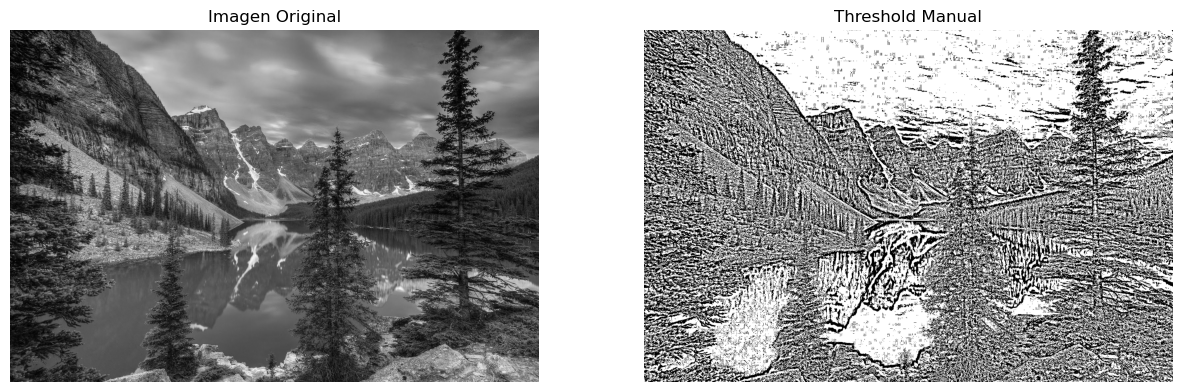

In [5]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen.jpg', 0)  # Escala de grises

ventana = 15
k = 2

def adaptive_mean_threshold(imagen, ventana, k):
    alto, ancho = imagen.shape
    salida = np.zeros_like(imagen)
    
    pad = ventana // 2
    imagen_padded = np.pad(imagen, pad, mode='reflect')
    
    for i in range(alto):
        for j in range(ancho):
            # Extraer ventana local
            region = imagen_padded[i:i+ventana, j:j+ventana]
            
            # Calcular media
            media = np.mean(region)
            
            # Aplicar fórmula
            T = media - k
            
            # Umbral binario
            if imagen[i, j] > T:
                salida[i, j] = 255
            else:
                salida[i, j] = 0
    
    return salida

imagen_fin = adaptive_mean_threshold(imagen, ventana, k)

plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Threshold Manual')
plt.imshow(imagen_fin, cmap='gray')
plt.axis('off')

plt.show()